In [ ]:
from google.colab import files
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string

# Language detection
try:
    from langdetect import detect, DetectorFactory
    DetectorFactory.seed = 0  # For consistent results
    LANGDETECT_AVAILABLE = True
    print("✅ Language detection available")
except ImportError:
    print("⚠️ Installing langdetect for language detection...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "langdetect"])
    from langdetect import detect, DetectorFactory
    DetectorFactory.seed = 0
    LANGDETECT_AVAILABLE = True
    print("✅ Language detection installed and ready")

# Download required NLTK data
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab') # Add this line to download the missing resource

# Upload and read the file
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

def detect_language(text):
    """
    Detect language of text. Returns 'en' for English, other codes for other languages
    """
    if pd.isna(text) or str(text).strip() == '' or len(str(text).strip()) < 3:
        return 'unknown'

    try:
        # Clean text a bit for better detection
        clean_text = re.sub(r'[^\w\s]', ' ', str(text))  # Remove special characters
        clean_text = re.sub(r'\s+', ' ', clean_text).strip()  # Clean whitespace

        if len(clean_text) < 3:
            return 'unknown'

        detected_lang = detect(clean_text)
        return detected_lang
    except:
        return 'unknown'

def analyze_languages(df, text_column='text', sample_size=None):
    """
    Analyze language distribution in the dataset
    """
    print("🔍 LANGUAGE ANALYSIS")
    print("-" * 40)

    # Use sample for large datasets to speed up analysis
    if sample_size and len(df) > sample_size:
        print(f"📊 Analyzing language for {sample_size:,} random samples (out of {len(df):,} total)")
        sample_df = df.sample(n=sample_size, random_state=42)
    else:
        print(f"📊 Analyzing language for all {len(df):,} comments")
        sample_df = df

    # Detect languages
    print("🔄 Detecting languages... (this may take a moment)")
    sample_df = sample_df.copy()
    sample_df['detected_language'] = sample_df[text_column].apply(detect_language)

    # Language statistics
    lang_counts = sample_df['detected_language'].value_counts()
    total_detected = len(sample_df[sample_df['detected_language'] != 'unknown'])

    print(f"\n📈 LANGUAGE DISTRIBUTION:")
    print("-" * 30)

    for lang, count in lang_counts.items():
        percentage = (count / len(sample_df)) * 100
        if lang == 'en':
            print(f"🇺🇸 English (en): {count:,} comments ({percentage:.1f}%)")
        elif lang == 'unknown':
            print(f"❓ Unknown/Too short: {count:,} comments ({percentage:.1f}%)")
        else:
            language_names = {
                'es': '🇪🇸 Spanish', 'fr': '🇫🇷 French', 'de': '🇩🇪 German', 'it': '🇮🇹 Italian',
                'pt': '🇧🇷 Portuguese', 'ru': '🇷🇺 Russian', 'ja': '🇯🇵 Japanese', 'ko': '🇰🇷 Korean',
                'zh-cn': '🇨🇳 Chinese', 'ar': '🇸🇦 Arabic', 'hi': '🇮🇳 Hindi', 'tr': '🇹🇷 Turkish',
                'nl': '🇳🇱 Dutch', 'sv': '🇸🇪 Swedish', 'da': '🇩🇰 Danish', 'no': '🇳🇴 Norwegian',
                'fi': '🇫🇮 Finnish', 'pl': '🇵🇱 Polish', 'cs': '🇨🇿 Czech', 'hu': '🇭🇺 Hungarian'
            }
            display_name = language_names.get(lang, f"🌍 {lang.upper()}")
            print(f"{display_name}: {count:,} comments ({percentage:.1f}%)")

    # English percentage calculation
    english_count = lang_counts.get('en', 0)
    english_percentage = (english_count / total_detected) * 100 if total_detected > 0 else 0

    print(f"\n🎯 KEY METRICS:")
    print(f"   📊 English Comments: {english_count:,} ({english_percentage:.1f}% of detectable)")
    print(f"   📊 Non-English Comments: {total_detected - english_count:,}")
    print(f"   📊 Unknown/Short Comments: {lang_counts.get('unknown', 0):,}")

    # Recommendation
    if english_percentage >= 80:
        print(f"\n✅ RECOMMENDATION: {english_percentage:.1f}% English - Good for English analysis")
        print("   💡 You can safely filter to English-only comments")
    elif english_percentage >= 60:
        print(f"\n⚠️  RECOMMENDATION: {english_percentage:.1f}% English - Moderate English content")
        print("   💡 Consider filtering to English-only for cleaner analysis")
    else:
        print(f"\n❌ RECOMMENDATION: Only {english_percentage:.1f}% English - Mixed language dataset")
        print("   💡 Consider multilingual analysis or manual review")

    return sample_df, lang_counts

def filter_english_comments(df, text_column='text'):
    """
    Filter dataset to keep only English comments
    """
    print("🔄 Filtering to English comments only...")

    # Detect language for all comments
    df_copy = df.copy()
    df_copy['detected_language'] = df_copy[text_column].apply(detect_language)

    # Filter to English only
    english_df = df_copy[df_copy['detected_language'] == 'en'].copy()
    english_df = english_df.drop('detected_language', axis=1)  # Remove temp column

    original_count = len(df)
    english_count = len(english_df)
    removed_count = original_count - english_count

    print(f"✅ English filtering complete!")
    print(f"   📊 Original comments: {original_count:,}")
    print(f"   📊 English comments: {english_count:,}")
    print(f"   📊 Removed comments: {removed_count:,} ({(removed_count/original_count)*100:.1f}%)")

    return english_df

# STEP 1: LANGUAGE ANALYSIS
print("="*60)
print("🌍 STEP 1: LANGUAGE DETECTION & ANALYSIS")
print("="*60)

# Analyze languages (use sample of 1000 for speed on large datasets)
sample_df, lang_stats = analyze_languages(df, text_column='text', sample_size=1000)

# Ask user if they want to filter to English only
english_percentage = (lang_stats.get('en', 0) / len(sample_df[sample_df['detected_language'] != 'unknown'])) * 100

print(f"\n🤔 DECISION POINT:")
print(f"Current dataset has {english_percentage:.1f}% English comments.")
print("Do you want to filter to English-only comments? (Recommended if >70% English)")
print("\n💡 INSTRUCTIONS:")
print("   - If you want English-only: Uncomment the filtering code below")
print("   - If you want to keep all languages: Leave the code commented")

print(f"\n# ===== ENGLISH FILTERING CODE (UNCOMMENT IF DESIRED) =====")
print(f"# Uncomment the lines below to filter to English-only comments:")
print(f"#")
print(f"# print('\\n🔄 APPLYING ENGLISH FILTER...')")
print(f"# df = filter_english_comments(df, text_column='text')")
print(f"# print('✅ English filtering applied!')")
print(f"# ===== END ENGLISH FILTERING CODE =====")

# ENGLISH FILTERING CODE (UNCOMMENT IF YOU WANT ENGLISH ONLY)
print('\n🔄 APPLYING ENGLISH FILTER...')
df = filter_english_comments(df, text_column='text')
print('✅ English filtering applied!')

print(f"\n🧹 STEP 2: ADVANCED TEXT CLEANING")
print("="*50)

def advanced_clean_text(text):
    """
    Comprehensive text cleaning function for YouTube comments
    """
    if pd.isna(text) or text == '':
        return ''

    # Convert to string and lowercase
    text = str(text).lower()

    # FIRST: Protect years early before any other processing
    years = re.findall(r'\b(199[5-9]|20[0-2][0-5])\b', text)
    year_placeholders = {}
    for i, year in enumerate(years):
        placeholder = f"YEAREARLY{i}PROTECT"
        year_placeholders[placeholder] = year
        text = text.replace(year, placeholder)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)

    # Remove mentions (@username)
    text = re.sub(r'@\w+', '', text)

    # Remove hashtags but keep the text after #
    text = re.sub(r'#(\w+)', r'\1', text)

    # Remove timestamps (e.g., "1:23", "12:34:56")
    text = re.sub(r'\b\d{1,2}:\d{2}(?::\d{2})?\b', '', text)

    # Remove common YouTube spam patterns
    text = re.sub(r'first|second|third|fourth|fifth', '', text)  # "First!" comments
    text = re.sub(r'\bpin\s+me\b|\bpin\s+this\b', '', text)  # Pin requests
    text = re.sub(r'\bsub\s+for\s+sub\b|\bs4s\b', '', text)  # Sub4sub
    text = re.sub(r'\blike\s+if\b|\bheart\s+if\b', '', text)  # Like begging

    # Fix common internet slang and elongated words
    text = re.sub(r'\b([a-z])\1{2,}\b', r'\1\1', text)  # "sooooo" -> "soo"
    text = re.sub(r'\byassss+\b', 'yes', text)
    text = re.sub(r'\bnoooo+\b', 'no', text)
    text = re.sub(r'\bwowww+\b', 'wow', text)
    text = re.sub(r'\bomggg+\b', 'omg', text)

    # Replace common abbreviations and internet slang
    replacements = {
        r'\bu\b': 'you',
        r'\bur\b': 'your',
        r'\br\b': 'are',
        r'\btbh\b': 'to be honest',
        r'\bidk\b': 'i dont know',
        r'\bomg\b': 'oh my god',
        r'\blol\b': 'laugh out loud',
        r'\blmao\b': 'laughing',
        r'\bbtw\b': 'by the way',
        r'\bimo\b': 'in my opinion',
        r'\bimho\b': 'in my opinion',
        r'\bsmh\b': 'shaking my head',
        r'\bfr\b': 'for real',
        r'\bngl\b': 'not gonna lie',
        r'\bicymi\b': 'in case you missed it'
    }

    for abbrev, full in replacements.items():
        text = re.sub(abbrev, full, text)

    # Remove emojis and special unicode characters
    text = re.sub(r'[^\x00-\x7F]+', '', text)

    # Remove excessive punctuation (more than 2 consecutive)
    text = re.sub(r'[.]{3,}', '...', text)
    text = re.sub(r'[!]{2,}', '!', text)
    text = re.sub(r'[?]{2,}', '?', text)

    # Remove excessive capitalization (3+ caps in a row)
    text = re.sub(r'[A-Z]{3,}', lambda m: m.group().lower(), text)

    # Remove ALL remaining numbers (years are already protected)
    text = re.sub(r'\d+', '', text)

    # Remove extra whitespace and newlines
    text = re.sub(r'\s+', ' ', text)

    # Remove punctuation except periods, exclamation marks, and question marks
    text = re.sub(r'[^\w\s.!?]', ' ', text)

    # Remove very short words (1-2 characters) that are likely noise, but preserve meaningful short words
    # First protect meaningful short words
    meaningful_short_words = ['no', 'ok', 'go', 'me', 'we', 'he', 'do', 'so', 'to', 'my', 'of', 'on', 'in', 'at', 'be', 'or', 'if', 'it', 'up', 'us']
    protected_words = {}

    for i, word in enumerate(meaningful_short_words):
        if re.search(r'\b' + word + r'\b', text):
            placeholder = f"WORD{i}PROTECT"
            protected_words[placeholder] = word
            text = re.sub(r'\b' + word + r'\b', placeholder, text)

    # Now remove remaining short words (likely noise)
    text = re.sub(r'\b\w{1,2}\b', '', text)

    # Restore meaningful words
    for placeholder, word in protected_words.items():
        text = text.replace(placeholder, word)

    # FINALLY: Restore years at the very end
    for placeholder, year in year_placeholders.items():
        text = text.replace(placeholder, year)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

def remove_stopwords(text):
    """
    Remove common English stopwords
    """
    stop_words = set(stopwords.words('english'))
    word_tokens = word_tokenize(text)
    filtered_text = [word for word in word_tokens if word.lower() not in stop_words and len(word) > 2]
    return ' '.join(filtered_text)

# Apply cleaning functions
print("Original data shape:", df.shape)
print("\nFirst few original comments:")
print(df['text'].head())

# Ensure text column is string type
df['text'] = df['text'].astype(str)

# Apply advanced cleaning
df['cleaned_text'] = df['text'].apply(advanced_clean_text)

# Optional: Remove stopwords (uncomment if needed)
df['cleaned_no_stopwords'] = df['cleaned_text'].apply(remove_stopwords)

# Remove empty or very short comments after cleaning
df = df[df['cleaned_text'].str.len() > 5]

# Select relevant columns
df_selected = df[['text', 'likes', 'cleaned_text', 'published_at']]

print(f"\nData shape after cleaning: {df_selected.shape}")
print("\nCleaned comments preview:")
print(df_selected[['text', 'cleaned_text']].head())

# Display statistics
print(f"\nAverage original comment length: {df_selected['text'].str.len().mean():.1f} characters")
print(f"Average cleaned comment length: {df_selected['cleaned_text'].str.len().mean():.1f} characters")

# Show the final dataframe
df_selected.head(10)

✅ Language detection available


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Saving youtube_commentary_video_comments (1).csv to youtube_commentary_video_comments (1) (3).csv
🌍 STEP 1: LANGUAGE DETECTION & ANALYSIS
🔍 LANGUAGE ANALYSIS
----------------------------------------
📊 Analyzing language for 1,000 random samples (out of 4,557 total)
🔄 Detecting languages... (this may take a moment)

📈 LANGUAGE DISTRIBUTION:
------------------------------
🇺🇸 English (en): 934 comments (93.4%)
🇩🇪 German: 9 comments (0.9%)
🇳🇴 Norwegian: 9 comments (0.9%)
🌍 AF: 7 comments (0.7%)
❓ Unknown/Too short: 6 comments (0.6%)
🌍 CA: 6 comments (0.6%)
🇵🇱 Polish: 5 comments (0.5%)
🇮🇹 Italian: 4 comments (0.4%)
🌍 ET: 3 comments (0.3%)
🇳🇱 Dutch: 2 comments (0.2%)
🇩🇰 Danish: 2 comments (0.2%)
🌍 CY: 2 comments (0.2%)
🌍 ID: 2 comments (0.2%)
🌍 SO: 2 comments (0.2%)
🇧🇷 Portuguese: 1 comments (0.1%)
🌍 SK: 1 comments (0.1%)
🇪🇸 Spanish: 1 comments (0.1%)
🇫🇷 French: 1 comments (0.1%)
🌍 HR: 1 comments (0.1%)
🌍 SL: 1 comments (0.1%)
🌍 VI: 1 comments (0.1%)

🎯 KEY METRICS:
   📊 English Comments: 93

,text,likes,cleaned_text,published_at
0,Nowadays people cry if they don't see a fat pe...,0,nowadays people cry if they don see fat person...,2025-08-16T15:25:52Z
1,I'd rather see VS die with their high standard...,0,rather see die with their high standards than ...,2025-07-13T09:05:00Z
2,The last show I watched was the 2018 one fast-...,0,the last show watched was the one fast forward...,2025-03-23T07:01:21Z
3,We want BEAUTY and we want SKINNY. We want to ...,0,we want beauty and we want skinny. we want to ...,2025-02-18T23:23:31Z
5,the set design in general was so lackluster. i...,0,the set design in general was so lackluster. i...,2024-12-16T20:47:36Z
6,damn they have to lose weight and work out lik...,0,damn they have to lose weight and work out lik...,2024-12-09T09:38:46Z
7,"They have no more great looking underwear, eve...",2,they have no more great looking underwear ever...,2024-12-02T02:40:47Z
8,I would be extremely sad if V.S. ceased to exi...,0,would be extremely sad if .. ceased to exist. ...,2024-11-25T20:01:19Z
9,Not enough black models either,0,not enough black models either,2024-11-19T00:23:55Z
12,What Doutzen deserves for being a crazy anti-v...,0,what doutzen deserves for being crazy anti vaxxer,2024-11-10T19:21:12Z


In [ ]:
!pip install textstat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 239.2/239.2 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 17.7 MB/s eta 0:00:00


🔍 GENERATING COMPREHENSIVE VS ANALYSIS REPORT
📊 VICTORIA'S SECRET COMMENT ANALYSIS
Total Comments Analyzed: 4,241
Average Comment Length: 178.4 characters
Total Engagement (Likes): 71,538
Average Engagement per Comment: 16.9

🛍️ PRODUCT CATEGORY MENTIONS:
Bras: 693 mentions
Panties: 195 mentions
Sleepwear: 21 mentions
Makeup: 10 mentions
Fragrance: 49 mentions
Activewear: 64 mentions

🔍 Performing VS-Specific Sentiment Analysis...

💕 VS SENTIMENT ANALYSIS
Neutral: 1,722 (40.6%)
Positive: 851 (20.1%)
Very Positive: 656 (15.5%)
Very Negative: 508 (12.0%)
Negative: 504 (11.9%)

🎯 VS TOPIC MODELING (Product-focused)
🔍 Performing VS Topic Modeling using LDA...

🎯 VS TOPIC MODELING RESULTS:
Topic 1 - Lingerie & Fit: store, underwear, last, body positive, online, gorgeous, support, wear
Topic 2 - Product Quality: love, care, pink, white, black, color, dark, feminine
Topic 3 - Lingerie & Fit: sexy, wear, curvy, bra, style, cheap, body type, comfortable
Topic 4 - General Discussion: brand, beau

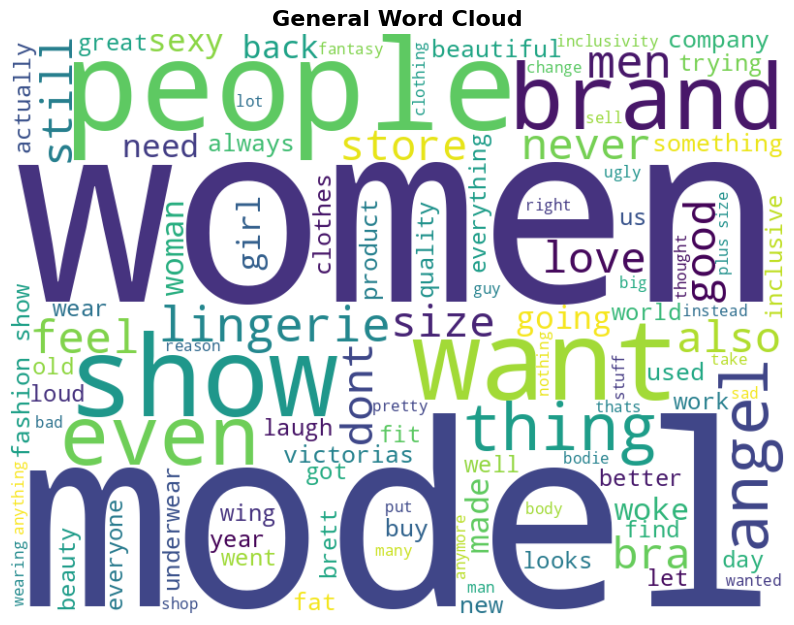


🔍 VS ASPECT-BASED SENTIMENT
🔍 Performing VS Aspect-Based Sentiment Analysis...


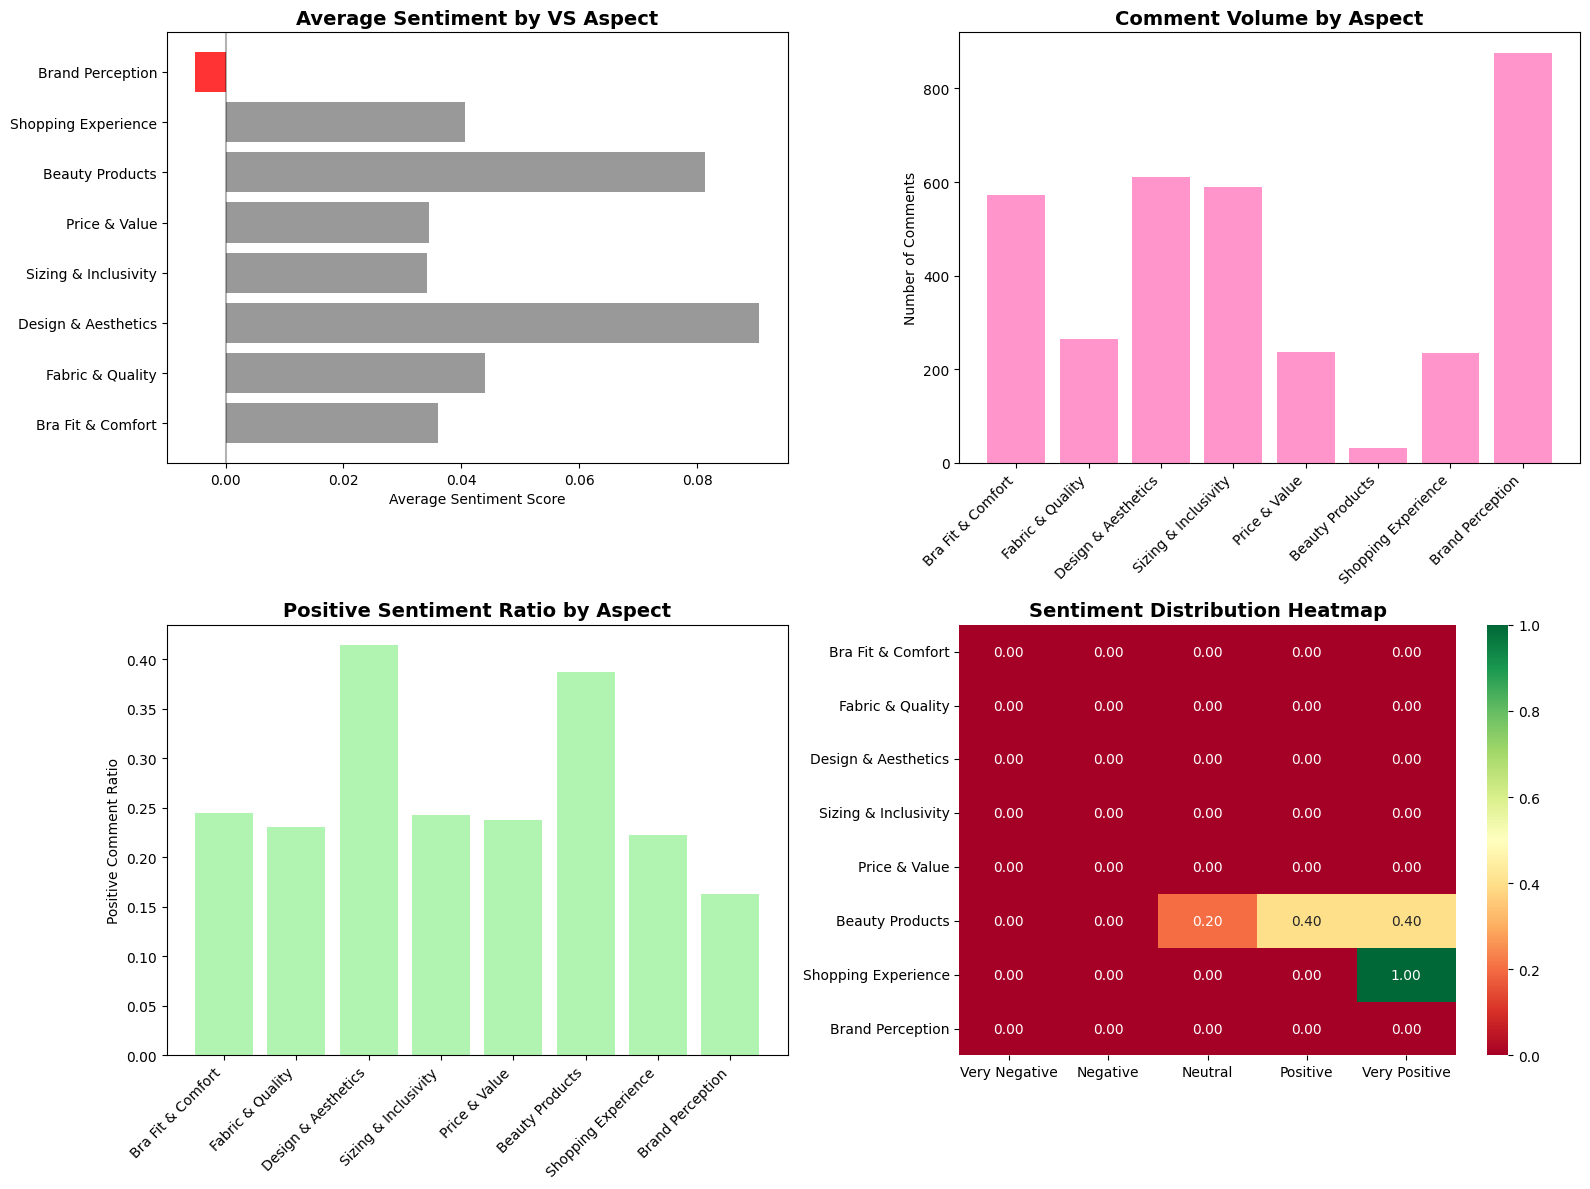

\n📊 VS ASPECT-BASED SENTIMENT INSIGHTS:
\nDesign & Aesthetics:
  📈 Sentiment: Positive (Score: 0.091)
  💬 Comments: 611
  👍 Positive Ratio: 41.4%
  👎 Negative Ratio: 2.6%
  ✅ Sample Positive: nowadays people cry if they don see fat person or lgbtq person on screen. the only diversity like to...
  ❌ Sample Negative: collections didn have themes. color no theme. it made clothes boring uninspired. for example how int...
\nBeauty Products:
  📈 Sentiment: Positive (Score: 0.081)
  💬 Comments: 31
  👍 Positive Ratio: 38.7%
  👎 Negative Ratio: 3.2%
  ✅ Sample Positive: makeup mirrors and artist that what they all are but when you have to go hungry to keep your job. it...
  ❌ Sample Negative: victorias quality going downhill while the price going up. the garments are not durable they used to...
\nFabric & Quality:
  📈 Sentiment: Neutral (Score: 0.044)
  💬 Comments: 264
  👍 Positive Ratio: 23.1%
  👎 Negative Ratio: 5.3%
  ✅ Sample Positive: their products are very cheaply made and very flimsy. c

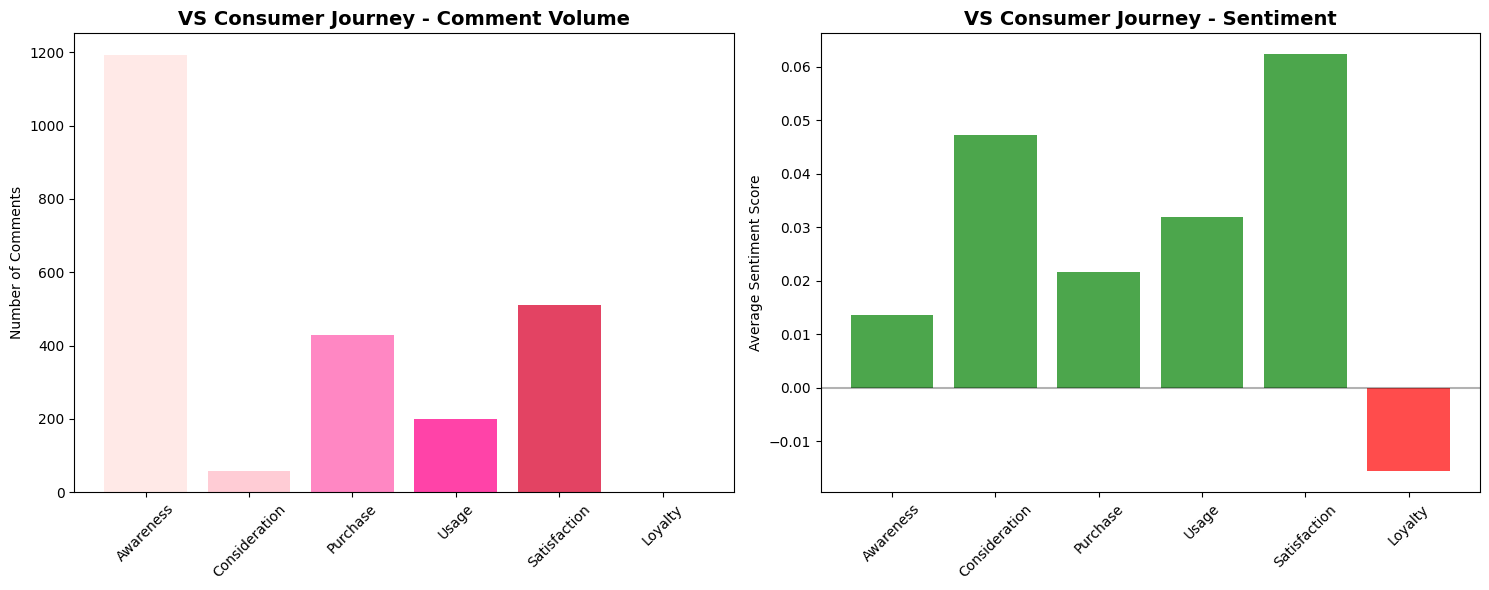


📊 CONSUMER JOURNEY INSIGHTS:
Awareness: 1192 comments, Sentiment: 0.014
Consideration: 57 comments, Sentiment: 0.047
Purchase: 429 comments, Sentiment: 0.022
Usage: 200 comments, Sentiment: 0.032
Satisfaction: 510 comments, Sentiment: 0.062
Loyalty: 1 comments, Sentiment: -0.016

🏆 COMPETITIVE ANALYSIS
🔍 Performing VS Competitive Analysis...


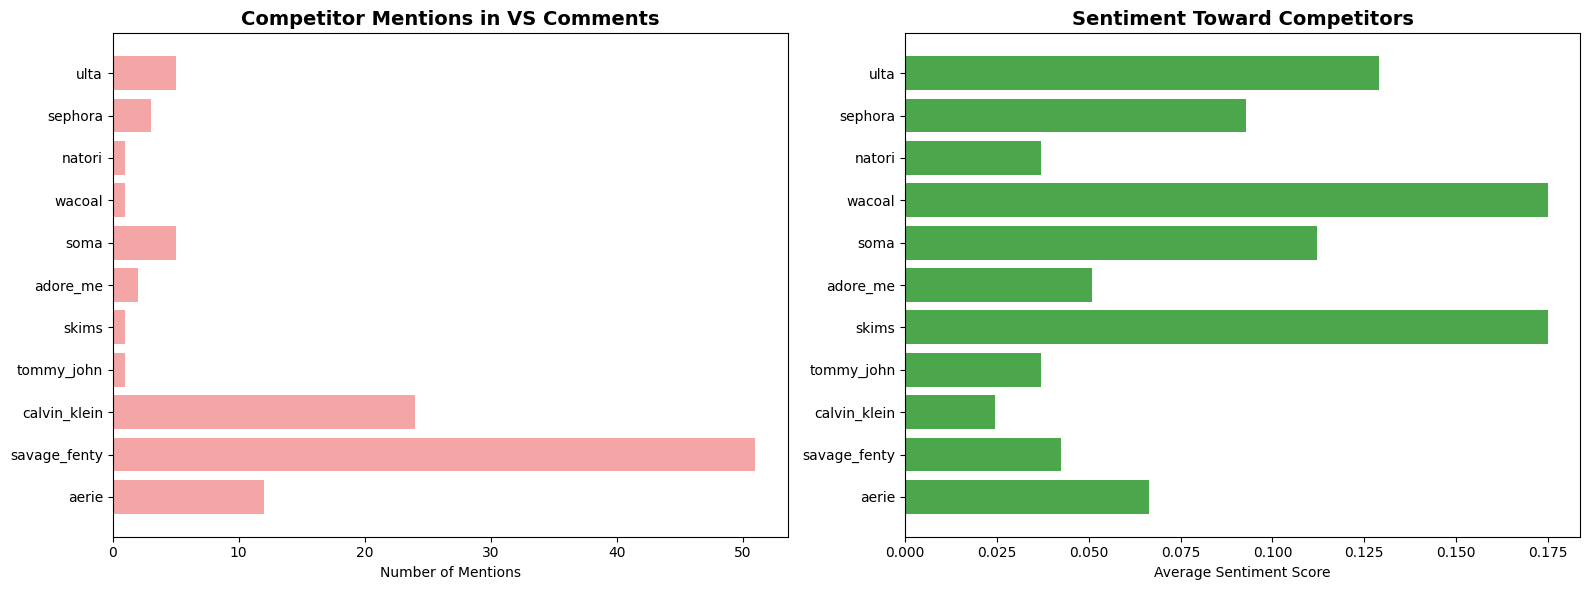


📊 COMPETITIVE ANALYSIS RESULTS:
Savage Fenty: 51 mentions, Neutral sentiment (0.043)
Calvin Klein: 24 mentions, Neutral sentiment (0.024)
Aerie: 12 mentions, Positive sentiment (0.066)
Soma: 5 mentions, Positive sentiment (0.112)
Ulta: 5 mentions, Positive sentiment (0.129)
Sephora: 3 mentions, Positive sentiment (0.093)
Adore Me: 2 mentions, Positive sentiment (0.051)
Tommy John: 1 mentions, Neutral sentiment (0.037)
Skims: 1 mentions, Positive sentiment (0.175)
Wacoal: 1 mentions, Positive sentiment (0.175)
Natori: 1 mentions, Neutral sentiment (0.037)

📏 SIZING & FIT ANALYSIS
🔍 Performing VS Sizing & Fit Analysis...


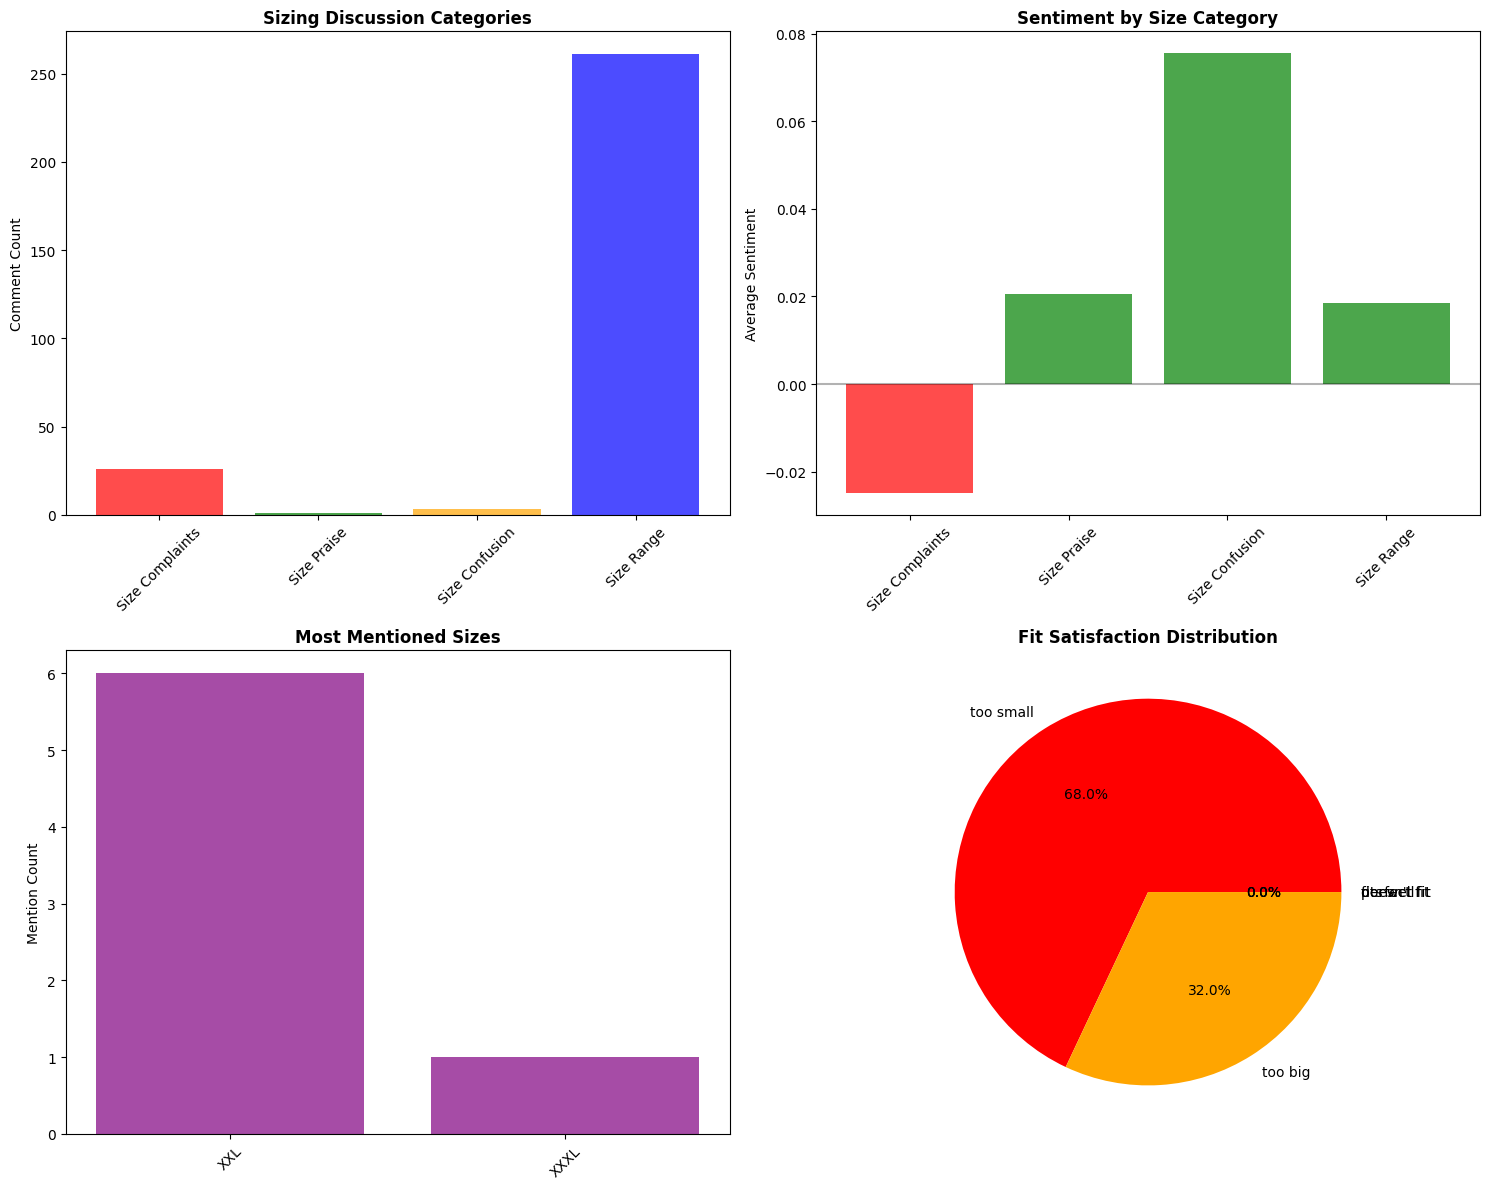


💎 BRAND LOYALTY ANALYSIS
🔍 Performing VS Brand Loyalty Analysis...


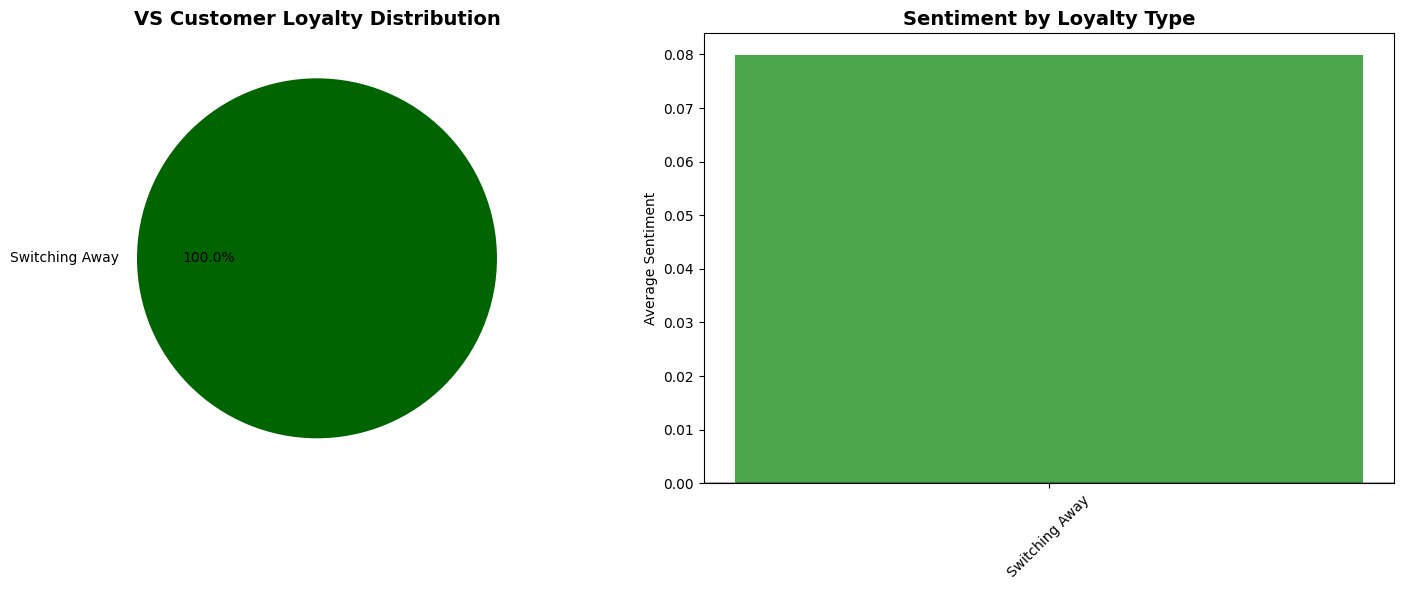


🎨 GENERATING VS VISUALIZATIONS...


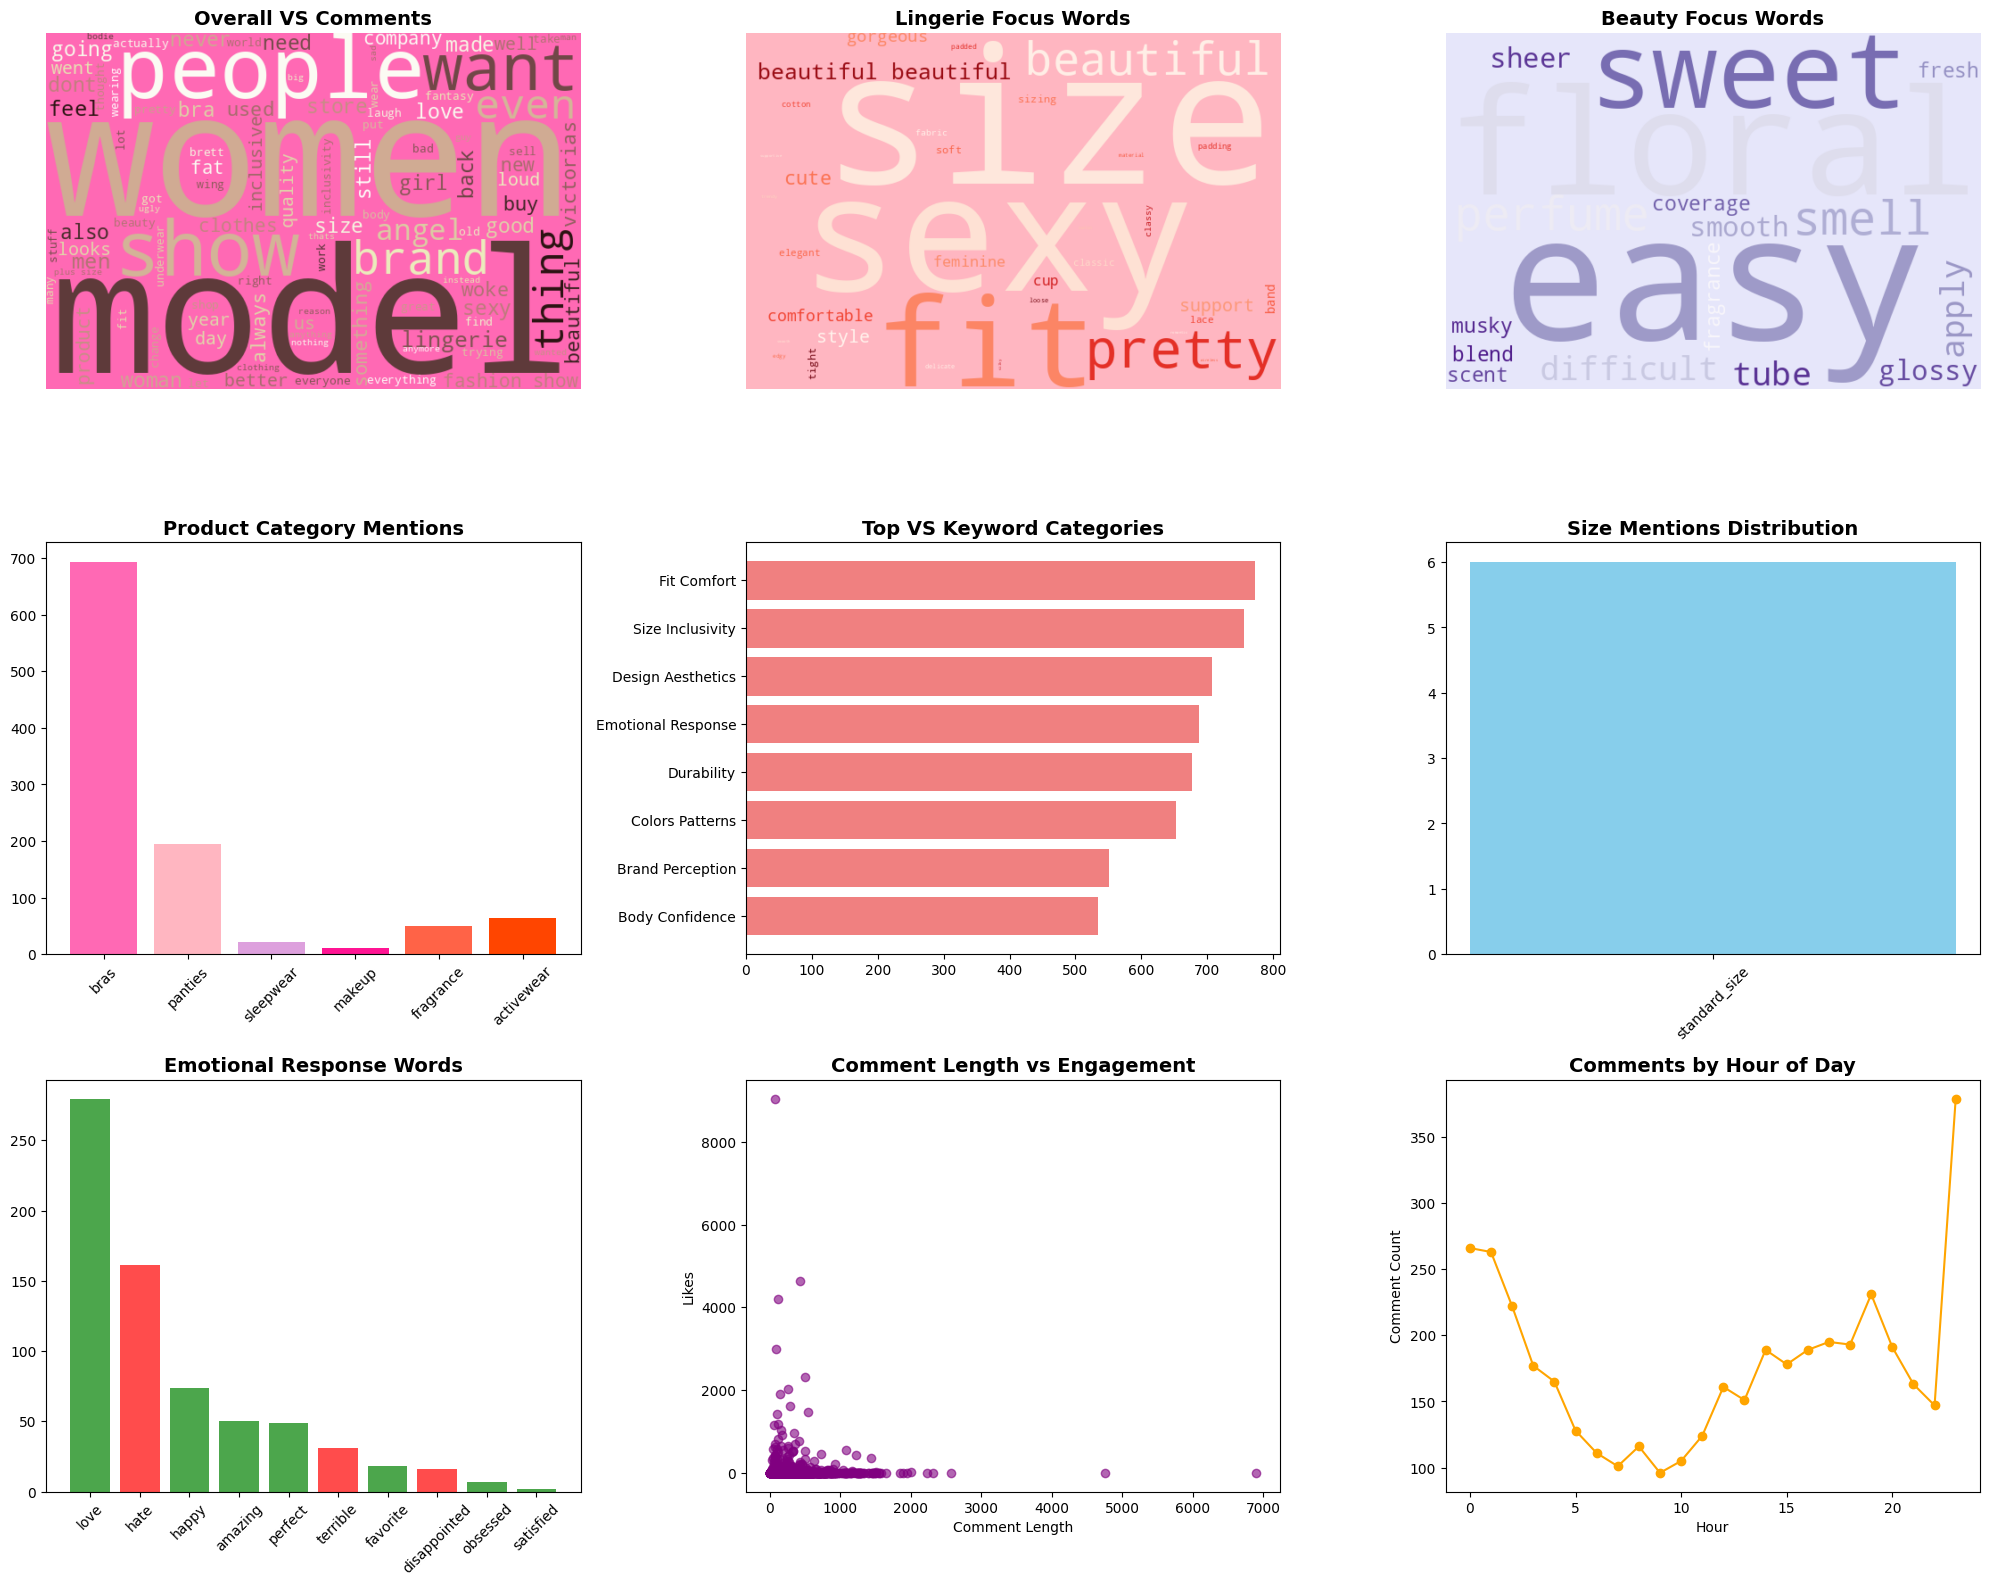


✅ COMPREHENSIVE VS ANALYSIS COMPLETE!


In [ ]:
# Victoria's Secret YouTube Comments Analysis Toolkit
# Specialized for Lingerie, Cosmetics, and Fashion Brand Analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from textblob import TextBlob
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import networkx as nx
from textstat import flesch_reading_ease, flesch_kincaid_grade
import warnings
warnings.filterwarnings('ignore')

# Download required NLTK data
try:
    nltk.download('vader_lexicon', quiet=True)
    nltk.download('stopwords', quiet=True)
    nltk.download('punkt', quiet=True)
except:
    pass

class VictoriasSecretAnalyzer:
    def __init__(self, df, text_column='cleaned_text'):
        self.df = df.copy()
        self.text_column = text_column
        self.stop_words = set(stopwords.words('english'))

        # VS-specific stop words
        self.vs_stopwords = {
            'video', 'channel', 'youtube', 'subscribe', 'comment', 'like', 'watch',
            'victoria', 'secret', 'vs', 'said', 'say', 'think', 'know', 'see', 'look',
            'get', 'go', 'make', 'one', 'would', 'could', 'really', 'much', 'way', 'time'
        }
        self.stop_words.update(self.vs_stopwords)

        # Victoria's Secret specific domain keywords (based on lingerie/cosmetics research)
        self.vs_keywords = {
            # Lingerie-specific attributes (based on intimate apparel research)
            'fit_comfort': ['fit', 'comfortable', 'support', 'supportive', 'snug', 'loose', 'tight', 'size', 'sizing', 'cup', 'band', 'underwire', 'wireless', 'padding', 'padded'],
            'fabric_quality': ['fabric', 'material', 'soft', 'smooth', 'silky', 'cotton', 'lace', 'satin', 'mesh', 'breathable', 'stretchy', 'elastic', 'delicate', 'sturdy'],
            'design_aesthetics': ['beautiful', 'gorgeous', 'sexy', 'cute', 'pretty', 'elegant', 'classy', 'romantic', 'feminine', 'edgy', 'bold', 'classic', 'trendy', 'style'],
            'colors_patterns': ['color', 'shade', 'pink', 'black', 'white', 'red', 'nude', 'floral', 'stripe', 'leopard', 'solid', 'print', 'pattern', 'bright', 'dark'],

            # Cosmetics-specific (VS beauty line research)
            'makeup_quality': ['pigment', 'coverage', 'blend', 'smooth', 'creamy', 'matte', 'glossy', 'shimmer', 'buildable', 'opaque', 'sheer'],
            'fragrance_notes': ['scent', 'smell', 'fragrance', 'perfume', 'sweet', 'floral', 'vanilla', 'fruity', 'fresh', 'musky', 'long lasting', 'subtle'],
            'application_ease': ['apply', 'application', 'easy', 'difficult', 'brush', 'wand', 'tube', 'pump', 'spray', 'smooth application'],

            # Price/Value perception (luxury positioning research)
            'price_value': ['expensive', 'pricey', 'affordable', 'worth', 'value', 'money', 'budget', 'splurge', 'investment', 'cheap', 'overpriced'],
            'brand_perception': ['brand', 'quality', 'luxury', 'high end', 'premium', 'iconic', 'classic', 'reputation', 'status', 'prestige'],

            # Body positivity & confidence (important for intimate apparel)
            'body_confidence': ['confident', 'sexy', 'beautiful', 'empowered', 'comfortable', 'self-conscious', 'insecure', 'body positive', 'flattering'],
            'size_inclusivity': ['size', 'plus size', 'petite', 'curvy', 'inclusive', 'range', 'fit everyone', 'all sizes', 'body type'],

            # Shopping experience (omnichannel research)
            'shopping_experience': ['store', 'online', 'website', 'delivery', 'shipping', 'return', 'exchange', 'customer service', 'staff', 'helpful'],

            # Durability & longevity
            'durability': ['durable', 'last', 'wear', 'wash', 'fade', 'shrink', 'tear', 'quality', 'hold up', 'maintain', 'care'],

            # Emotional responses (brand attachment research)
            'emotional_response': ['love', 'obsessed', 'favorite', 'disappointed', 'hate', 'amazing', 'perfect', 'terrible', 'satisfied', 'happy']
        }

        # VS-specific product categories
        self.product_categories = {
            'bras': ['bra', 'bras', 'push up', 'pushup', 'sports bra', 'bralette', 'strapless', 'plunge', 'demi', 'full coverage'],
            'panties': ['panty', 'panties', 'underwear', 'thong', 'bikini', 'brief', 'boyshort', 'cheeky', 'hipster'],
            'sleepwear': ['pajama', 'pjs', 'nightgown', 'robe', 'sleepwear', 'loungewear', 'sleep set'],
            'makeup': ['lipstick', 'lip gloss', 'eyeshadow', 'mascara', 'eyeliner', 'foundation', 'concealer', 'blush'],
            'fragrance': ['perfume', 'body spray', 'mist', 'lotion', 'fragrance', 'scent', 'body care'],
            'activewear': ['leggings', 'sports bra', 'workout', 'gym', 'athletic', 'yoga', 'running', 'fitness']
        }

    def preprocess_for_vs_analysis(self):
        """VS-specific preprocessing"""
        def vs_specific_cleaning(text):
            if pd.isna(text):
                return ''

            # Normalize VS-specific terms
            text = re.sub(r'\bvs\b', 'victoria secret', text, flags=re.IGNORECASE)
            text = re.sub(r'\bpink\s+vs\b', 'pink victoria secret', text, flags=re.IGNORECASE)

            # Normalize size mentions
            text = re.sub(r'\b(\d+)([a-e])\b', r'size \1\2', text, flags=re.IGNORECASE)
            text = re.sub(r'\bsize\s*(\d+)\s*([a-e])\b', r'size \1\2', text, flags=re.IGNORECASE)

            # Normalize product mentions
            text = re.sub(r'\bpush\s*up\b', 'pushup', text, flags=re.IGNORECASE)
            text = re.sub(r'\bsports?\s+bra\b', 'sportsbra', text, flags=re.IGNORECASE)

            return text.strip()

        self.df['vs_analysis_text'] = self.df[self.text_column].apply(vs_specific_cleaning)
        return self.df

    # 1. VS-SPECIFIC WORD CLOUDS AND INSIGHTS
    def generate_vs_wordclouds(self, figsize=(20, 16)):
        """Generate Victoria's Secret specific word clouds"""
        fig, axes = plt.subplots(3, 3, figsize=figsize)

        all_text = ' '.join(self.df[self.text_column].dropna())

        # 1. Overall VS Comments
        vs_wordcloud = WordCloud(width=600, height=400, background_color='#FF69B4',
                                colormap='pink', stopwords=self.stop_words, max_words=100).generate(all_text)
        axes[0,0].imshow(vs_wordcloud, interpolation='bilinear')
        axes[0,0].set_title('Overall VS Comments', fontsize=14, fontweight='bold')
        axes[0,0].axis('off')

        # 2. Lingerie-specific words
        lingerie_words = []
        for category in ['fit_comfort', 'fabric_quality', 'design_aesthetics']:
            lingerie_words.extend(self.vs_keywords[category])
        lingerie_text = ' '.join([word for word in all_text.split() if word.lower() in lingerie_words])

        if lingerie_text:
            lingerie_cloud = WordCloud(width=600, height=400, background_color='#FFB6C1',
                                     colormap='Reds', max_words=50).generate(lingerie_text)
            axes[0,1].imshow(lingerie_cloud, interpolation='bilinear')
        axes[0,1].set_title('Lingerie Focus Words', fontsize=14, fontweight='bold')
        axes[0,1].axis('off')

        # 3. Beauty/Cosmetics words
        beauty_words = []
        for category in ['makeup_quality', 'fragrance_notes', 'application_ease']:
            beauty_words.extend(self.vs_keywords[category])
        beauty_text = ' '.join([word for word in all_text.split() if word.lower() in beauty_words])

        if beauty_text:
            beauty_cloud = WordCloud(width=600, height=400, background_color='#E6E6FA',
                                   colormap='Purples', max_words=50).generate(beauty_text)
            axes[0,2].imshow(beauty_cloud, interpolation='bilinear')
        axes[0,2].set_title('Beauty Focus Words', fontsize=14, fontweight='bold')
        axes[0,2].axis('off')

        # 4. Product category frequency
        product_mentions = {}
        for category, products in self.product_categories.items():
            count = 0
            for product in products:
                count += sum(1 for text in self.df[self.text_column].dropna()
                           if product in text.lower())
            product_mentions[category] = count

        categories = list(product_mentions.keys())
        counts = list(product_mentions.values())

        axes[1,0].bar(categories, counts, color=['#FF69B4', '#FFB6C1', '#DDA0DD', '#FF1493', '#FF6347', '#FF4500'])
        axes[1,0].set_title('Product Category Mentions', fontsize=14, fontweight='bold')
        axes[1,0].tick_params(axis='x', rotation=45)

        # 5. VS keyword category analysis
        vs_category_counts = {}
        for category, keywords in self.vs_keywords.items():
            category_count = 0
            for keyword in keywords:
                category_count += sum(1 for text in self.df[self.text_column].dropna()
                                    if keyword in text.lower())
            vs_category_counts[category.replace('_', ' ').title()] = category_count

        # Plot top 8 categories
        sorted_categories = sorted(vs_category_counts.items(), key=lambda x: x[1], reverse=True)[:8]
        cat_names, cat_counts = zip(*sorted_categories)

        axes[1,1].barh(cat_names, cat_counts, color='lightcoral')
        axes[1,1].set_title('Top VS Keyword Categories', fontsize=14, fontweight='bold')
        axes[1,1].invert_yaxis()

        # 6. Size mentions analysis
        size_pattern = r'\b(?:size\s*)?(\d+)([a-e])\b|\b(?:xs|s|m|l|xl|xxl)\b'
        size_mentions = []
        for text in self.df[self.text_column].dropna():
            matches = re.findall(size_pattern, str(text).lower())
            size_mentions.extend([f"{m[0]}{m[1]}" if m[0] else "standard_size" for m in matches])

        if size_mentions:
            size_counter = Counter(size_mentions).most_common(10)
            sizes, size_counts = zip(*size_counter)
            axes[1,2].bar(sizes, size_counts, color='skyblue')
            axes[1,2].set_title('Size Mentions Distribution', fontsize=14, fontweight='bold')
            axes[1,2].tick_params(axis='x', rotation=45)
        else:
            axes[1,2].text(0.5, 0.5, 'No size mentions found', ha='center', va='center', transform=axes[1,2].transAxes)

        # 7. Emotional words analysis
        emotional_words = self.vs_keywords['emotional_response']
        emotion_counts = {}
        for emotion in emotional_words:
            emotion_counts[emotion] = sum(1 for text in self.df[self.text_column].dropna()
                                        if emotion in text.lower())

        sorted_emotions = sorted(emotion_counts.items(), key=lambda x: x[1], reverse=True)[:10]
        if sorted_emotions:
            emotions, e_counts = zip(*sorted_emotions)
            colors = ['green' if e in ['love', 'obsessed', 'favorite', 'amazing', 'perfect', 'satisfied', 'happy']
                     else 'red' for e in emotions]
            axes[2,0].bar(emotions, e_counts, color=colors, alpha=0.7)
            axes[2,0].set_title('Emotional Response Words', fontsize=14, fontweight='bold')
            axes[2,0].tick_params(axis='x', rotation=45)

        # 8. Comment length vs engagement (if likes available)
        if 'likes' in self.df.columns:
            lengths = self.df[self.text_column].str.len()
            likes = self.df['likes']
            axes[2,1].scatter(lengths, likes, alpha=0.6, color='purple')
            axes[2,1].set_xlabel('Comment Length')
            axes[2,1].set_ylabel('Likes')
            axes[2,1].set_title('Comment Length vs Engagement', fontsize=14, fontweight='bold')
        else:
            axes[2,1].text(0.5, 0.5, 'No engagement data', ha='center', va='center', transform=axes[2,1].transAxes)

        # 9. Time-based analysis (if available)
        if 'published_at' in self.df.columns:
            try:
                self.df['hour'] = pd.to_datetime(self.df['published_at']).dt.hour
                hourly_comments = self.df['hour'].value_counts().sort_index()
                axes[2,2].plot(hourly_comments.index, hourly_comments.values, marker='o', color='orange')
                axes[2,2].set_title('Comments by Hour of Day', fontsize=14, fontweight='bold')
                axes[2,2].set_xlabel('Hour')
                axes[2,2].set_ylabel('Comment Count')
            except:
                axes[2,2].text(0.5, 0.5, 'Time analysis failed', ha='center', va='center', transform=axes[2,2].transAxes)
        else:
            axes[2,2].text(0.5, 0.5, 'No timestamp data', ha='center', va='center', transform=axes[2,2].transAxes)

        plt.tight_layout()
        plt.show()

    # 2. VS-SPECIFIC SENTIMENT ANALYSIS
    def analyze_vs_sentiment(self):
        """Victoria's Secret specific sentiment analysis"""
        print("🔍 Performing VS-Specific Sentiment Analysis...")

        # Standard sentiment analysis
        self.df['textblob_polarity'] = self.df[self.text_column].apply(
            lambda x: TextBlob(str(x)).sentiment.polarity if pd.notnull(x) else 0
        )

        # VS-specific sentiment lexicon
        vs_positive_words = {
            'love', 'obsessed', 'amazing', 'perfect', 'gorgeous', 'beautiful', 'sexy', 'comfortable',
            'supportive', 'flattering', 'soft', 'smooth', 'elegant', 'classy', 'romantic', 'feminine',
            'pigmented', 'long lasting', 'buildable', 'blendable', 'worth it', 'investment', 'quality'
        }

        vs_negative_words = {
            'hate', 'terrible', 'awful', 'disappointed', 'uncomfortable', 'itchy', 'scratchy', 'cheap',
            'overpriced', 'poor quality', 'falls apart', 'doesn\'t fit', 'too small', 'too big',
            'chalky', 'patchy', 'streaky', 'fades quickly', 'smudges', 'not worth it'
        }

        def vs_sentiment_score(text):
            if pd.isnull(text):
                return 0
            text = str(text).lower()

            # Count VS-specific positive and negative words
            pos_count = sum(1 for word in vs_positive_words if word in text)
            neg_count = sum(1 for word in vs_negative_words if word in text)

            # Weight by text length
            text_length = len(text.split())
            if text_length == 0:
                return 0

            return (pos_count - neg_count) / max(text_length, 1)

        self.df['vs_sentiment'] = self.df[self.text_column].apply(vs_sentiment_score)

        # Combine general and VS-specific sentiment
        self.df['combined_sentiment'] = (self.df['textblob_polarity'] + self.df['vs_sentiment']) / 2

        # Categorize sentiment
        def categorize_sentiment(score):
            if score > 0.15:
                return 'Very Positive'
            elif score > 0.05:
                return 'Positive'
            elif score > -0.05:
                return 'Neutral'
            elif score > -0.15:
                return 'Negative'
            else:
                return 'Very Negative'

        self.df['sentiment_category'] = self.df['combined_sentiment'].apply(categorize_sentiment)

        return self.df

    # 3. VS-SPECIFIC TOPIC MODELING
    def perform_vs_topic_modeling(self, n_topics=6, method='lda'):
        """Topic modeling specifically for VS content"""
        print(f"🔍 Performing VS Topic Modeling using {method.upper()}...")

        # Prepare text with VS-specific preprocessing
        texts = self.df[self.text_column].dropna().tolist()

        # Custom VS vocabulary
        vs_vocabulary = set()
        for keywords in self.vs_keywords.values():
            vs_vocabulary.update(keywords)
        for products in self.product_categories.values():
            vs_vocabulary.update(products)

        if method.lower() == 'lda':
            vectorizer = CountVectorizer(
                max_features=800,
                stop_words=list(self.stop_words),
                ngram_range=(1, 3),  # Include trigrams for phrases like "push up bra"
                min_df=3,
                max_df=0.7,
                vocabulary=list(vs_vocabulary) if len(vs_vocabulary) > 100 else None
            )
            doc_term_matrix = vectorizer.fit_transform(texts)

            lda = LatentDirichletAllocation(n_components=n_topics, random_state=42, max_iter=20)
            lda.fit(doc_term_matrix)

            feature_names = vectorizer.get_feature_names_out()
            topics = []

            print("\n🎯 VS TOPIC MODELING RESULTS:")
            for topic_idx, topic in enumerate(lda.components_):
                top_words = [feature_names[i] for i in topic.argsort()[-15:][::-1]]
                topics.append(top_words)

                # Interpret topic based on VS context
                topic_interpretation = self.interpret_vs_topic(top_words)
                print(f"Topic {topic_idx + 1} - {topic_interpretation}: {', '.join(top_words[:8])}")

            # Assign topics to comments
            doc_topic_probs = lda.transform(doc_term_matrix)
            dominant_topics = doc_topic_probs.argmax(axis=1)

            valid_indices = self.df[self.text_column].dropna().index
            self.df['topic'] = np.nan
            self.df.loc[valid_indices, 'topic'] = dominant_topics

        return topics


    def interpret_vs_topic(self, top_words):
        """Interpret topic based on VS domain knowledge"""
        lingerie_indicators = ['bra', 'panties', 'fit', 'size', 'comfortable', 'support', 'cup', 'band']
        beauty_indicators = ['lipstick', 'fragrance', 'scent', 'color', 'pigment', 'application']
        quality_indicators = ['quality', 'soft', 'material', 'fabric', 'durable']
        price_indicators = ['price', 'expensive', 'worth', 'money', 'affordable']
        experience_indicators = ['store', 'online', 'delivery', 'customer service', 'staff']

        word_set = set([word.lower() for word in top_words])

        if len(word_set.intersection(lingerie_indicators)) >= 2:
            return "Lingerie & Fit"
        elif len(word_set.intersection(beauty_indicators)) >= 2:
            return "Beauty & Cosmetics"
        elif len(word_set.intersection(quality_indicators)) >= 2:
            return "Product Quality"
        elif len(word_set.intersection(price_indicators)) >= 1:
            return "Price & Value"
        elif len(word_set.intersection(experience_indicators)) >= 1:
            return "Shopping Experience"
        else:
            return "General Discussion"

    # 4. GENERAL TOPIC MODELING
    def perform_general_topic_modeling(self, n_topics=6, method='lda'):
        """General topic modeling without VS-specific constraints"""
        print(f"🔍 Performing GENERAL Topic Modeling using {method.upper()}...")

        # Prepare text
        texts = self.df[self.text_column].dropna().tolist()

        if method.lower() == 'lda':
            vectorizer = CountVectorizer(
                max_features=1500,
                stop_words=list(self.stop_words),
                ngram_range=(1, 2),  # Bigrams are usually enough for general context
                min_df=5,
                max_df=0.8
            )
            doc_term_matrix = vectorizer.fit_transform(texts)

            lda = LatentDirichletAllocation(n_components=n_topics, random_state=42, max_iter=20)
            lda.fit(doc_term_matrix)

            feature_names = vectorizer.get_feature_names_out()
            topics = []

            print("\n🎯 GENERAL TOPIC MODELING RESULTS:")
            for topic_idx, topic in enumerate(lda.components_):
                top_words = [feature_names[i] for i in topic.argsort()[-15:][::-1]]
                topics.append(top_words)

                # Interpret topic in a generic way
                topic_interpretation = self.interpret_general_topic(top_words)
                print(f"Topic {topic_idx + 1} - {topic_interpretation}: {', '.join(top_words[:8])}")

            # Assign topics to comments
            doc_topic_probs = lda.transform(doc_term_matrix)
            dominant_topics = doc_topic_probs.argmax(axis=1)

            valid_indices = self.df[self.text_column].dropna().index
            self.df['general_topic'] = np.nan
            self.df.loc[valid_indices, 'general_topic'] = dominant_topics

        return topics

    def interpret_general_topic(self, top_words):
        """Interpret topic in a general, heuristic way"""
        word_set = set([word.lower() for word in top_words])

        people_words = {'customer', 'staff', 'team', 'people', 'users', 'clients'}
        product_words = {'design', 'quality', 'material', 'style', 'feature'}
        digital_words = {'online', 'website', 'app', 'platform', 'review'}
        finance_words = {'price', 'cost', 'value', 'money', 'budget'}
        experience_words = {'service', 'support', 'delivery', 'experience'}

        if len(word_set.intersection(people_words)) >= 2:
            return "People / Stakeholders"
        elif len(word_set.intersection(product_words)) >= 2:
            return "Product / Features"
        elif len(word_set.intersection(digital_words)) >= 2:
            return "Digital / Online"
        elif len(word_set.intersection(finance_words)) >= 1:
            return "Finance / Value"
        elif len(word_set.intersection(experience_words)) >= 1:
            return "Customer Experience"
        else:
            return f"Theme: {top_words[0].title()} & {top_words[1].title()}"


    # Add this method to the class
    def generate_general_wordclouds(self, figsize=(10, 8)):
        """Generate general word cloud from cleaned text"""
        print("\n🎨 Generating General Word Cloud...")
        all_text = ' '.join(self.df[self.text_column].dropna())
        wordcloud = WordCloud(width=800, height=600, background_color='white',
                              stopwords=self.stop_words, max_words=100).generate(all_text)

        plt.figure(figsize=figsize)
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title('General Word Cloud', fontsize=16, fontweight='bold')
        plt.show()


    # 4. VS ASPECT-BASED SENTIMENT ANALYSIS
    def vs_aspect_sentiment_analysis(self):
        """Detailed aspect-based sentiment for VS products"""
        print("🔍 Performing VS Aspect-Based Sentiment Analysis...")

        aspects = {
            'Bra Fit & Comfort': ['fit', 'comfortable', 'support', 'cup', 'band', 'underwire', 'padding', 'size'],
            'Fabric & Quality': ['fabric', 'material', 'soft', 'quality', 'durable', 'cotton', 'lace', 'smooth'],
            'Design & Aesthetics': ['beautiful', 'sexy', 'pretty', 'design', 'style', 'color', 'pattern'],
            'Sizing & Inclusivity': ['size', 'sizing', 'fit', 'range', 'inclusive', 'plus size', 'petite'],
            'Price & Value': ['price', 'expensive', 'worth', 'value', 'money', 'affordable', 'overpriced'],
            'Beauty Products': ['lipstick', 'fragrance', 'makeup', 'scent', 'pigment', 'application'],
            'Shopping Experience': ['store', 'online', 'staff', 'service', 'delivery', 'return', 'website'],
            'Brand Perception': ['brand', 'victoria secret', 'vs', 'quality', 'reputation', 'luxury']
        }

        aspect_results = {}

        for aspect, keywords in aspects.items():
            aspect_comments = []
            aspect_sentiments = []
            sample_positive = []
            sample_negative = []

            for idx, text in self.df[self.text_column].dropna().items():
                text_lower = str(text).lower()
                if any(keyword in text_lower for keyword in keywords):
                    aspect_comments.append(text)

                    if 'combined_sentiment' in self.df.columns:
                        sentiment_score = self.df.loc[idx, 'combined_sentiment']
                        aspect_sentiments.append(sentiment_score)

                        # Collect sample comments
                        if sentiment_score > 0.1 and len(sample_positive) < 2:
                            sample_positive.append(text[:100] + "...")
                        elif sentiment_score < -0.1 and len(sample_negative) < 2:
                            sample_negative.append(text[:100] + "...")

            if aspect_sentiments:
                aspect_results[aspect] = {
                    'avg_sentiment': np.mean(aspect_sentiments),
                    'sentiment_std': np.std(aspect_sentiments),
                    'comment_count': len(aspect_comments),
                    'positive_ratio': sum(1 for s in aspect_sentiments if s > 0.1) / len(aspect_sentiments),
                    'negative_ratio': sum(1 for s in aspect_sentiments if s < -0.1) / len(aspect_sentiments),
                    'sample_positive': sample_positive,
                    'sample_negative': sample_negative
                }

        # Visualize results
        self.visualize_vs_aspect_sentiment(aspect_results)

        # === Added: Diversity / Representation Analysis ===
        print("\n🌍 VS Diversity & Representation Analysis...")
        diversity_keywords = [
            'diversity','diverse','representation','represent','inclusive','inclusion',
            'lgbt','lgbtq','gay','lesbian','trans','transgender','queer','fat','plus-size','plus size',
            'skinny','thin','race','racial','ethnic','black','white','asian','brown','body positive'
        ]
        div_pattern = re.compile(r'\b(' + '|'.join([re.escape(k) for k in diversity_keywords]) + r')\b', flags=re.I)

        diversity_comments = []
        diversity_sentiments = []

        for idx, text in self.df[self.text_column].dropna().items():
            text_lower = str(text).lower()
            if div_pattern.search(text_lower):
                diversity_comments.append(text)
                if 'combined_sentiment' in self.df.columns:
                    diversity_sentiments.append(self.df.loc[idx, 'combined_sentiment'])

        if diversity_comments:
            avg_div_sent = np.mean(diversity_sentiments) if diversity_sentiments else 0
            pos_ratio = sum(1 for s in diversity_sentiments if s > 0.05) / len(diversity_sentiments)
            neg_ratio = sum(1 for s in diversity_sentiments if s < -0.05) / len(diversity_sentiments)
            print(f"Total comments mentioning diversity/representation: {len(diversity_comments)}")
            print(f"Average sentiment: {avg_div_sent:.3f}")
            print(f"Positive ratio: {pos_ratio:.1%}, Negative ratio: {neg_ratio:.1%}")
            print("Sample comments:")
            for c in diversity_comments[:5]:
                print(f" - {c[:150]}...")
        else:
            print("No comments mentioning diversity/representation detected.")

        return aspect_results


    def visualize_vs_aspect_sentiment(self, aspect_results):
        """Visualize VS aspect sentiment analysis"""
        if not aspect_results:
            print("No aspect sentiments found!")
            return

        fig, axes = plt.subplots(2, 2, figsize=(16, 12))

        aspects = list(aspect_results.keys())
        avg_sentiments = [aspect_results[aspect]['avg_sentiment'] for aspect in aspects]
        comment_counts = [aspect_results[aspect]['comment_count'] for aspect in aspects]
        positive_ratios = [aspect_results[aspect]['positive_ratio'] for aspect in aspects]

        # 1. Average sentiment by aspect
        colors = ['darkred' if x < -0.1 else 'red' if x < 0 else 'gray' if x < 0.1 else 'lightgreen' if x < 0.2 else 'darkgreen' for x in avg_sentiments]
        bars = axes[0,0].barh(aspects, avg_sentiments, color=colors, alpha=0.8)
        axes[0,0].set_title('Average Sentiment by VS Aspect', fontsize=14, fontweight='bold')
        axes[0,0].set_xlabel('Average Sentiment Score')
        axes[0,0].axvline(x=0, color='black', linestyle='-', alpha=0.3)

        # 2. Comment volume by aspect
        axes[0,1].bar(range(len(aspects)), comment_counts, color='#FF69B4', alpha=0.7)
        axes[0,1].set_title('Comment Volume by Aspect', fontsize=14, fontweight='bold')
        axes[0,1].set_ylabel('Number of Comments')
        axes[0,1].set_xticks(range(len(aspects)))
        axes[0,1].set_xticklabels(aspects, rotation=45, ha='right')

        # 3. Positive sentiment ratio
        axes[1,0].bar(range(len(aspects)), positive_ratios, color='lightgreen', alpha=0.7)
        axes[1,0].set_title('Positive Sentiment Ratio by Aspect', fontsize=14, fontweight='bold')
        axes[1,0].set_ylabel('Positive Comment Ratio')
        axes[1,0].set_xticks(range(len(aspects)))
        axes[1,0].set_xticklabels(aspects, rotation=45, ha='right')

        # 4. Sentiment distribution heatmap
        sentiment_matrix = []
        categories = ['Very Negative', 'Negative', 'Neutral', 'Positive', 'Very Positive']

        for aspect in aspects:
            sentiments = []
            for idx, text in self.df[self.text_column].dropna().items():
                if any(keyword in str(text).lower() for keyword in [aspect.lower().replace(' & ', ' ').replace(' ', ' ')]):
                    if 'sentiment_category' in self.df.columns:
                        sentiments.append(self.df.loc[idx, 'sentiment_category'])

            if sentiments:
                aspect_dist = [sentiments.count(cat)/len(sentiments) for cat in categories]
                sentiment_matrix.append(aspect_dist)
            else:
                sentiment_matrix.append([0]*5)

        sns.heatmap(sentiment_matrix,
                   xticklabels=categories,
                   yticklabels=aspects,
                   annot=True,
                   fmt='.2f',
                   cmap='RdYlGn',
                   ax=axes[1,1])
        axes[1,1].set_title('Sentiment Distribution Heatmap', fontsize=14, fontweight='bold')

        plt.tight_layout()
        plt.show()

        # Print detailed insights
        print("\\n📊 VS ASPECT-BASED SENTIMENT INSIGHTS:")
        print("="*60)

        sorted_aspects = sorted(aspect_results.items(), key=lambda x: x[1]['avg_sentiment'], reverse=True)

        for aspect, data in sorted_aspects:
            sentiment_label = "Very Positive" if data['avg_sentiment'] > 0.15 else "Positive" if data['avg_sentiment'] > 0.05 else "Neutral" if data['avg_sentiment'] > -0.05 else "Negative" if data['avg_sentiment'] > -0.15 else "Very Negative"

            print(f"\\n{aspect}:")
            print(f"  📈 Sentiment: {sentiment_label} (Score: {data['avg_sentiment']:.3f})")
            print(f"  💬 Comments: {data['comment_count']:,}")
            print(f"  👍 Positive Ratio: {data['positive_ratio']:.1%}")
            print(f"  👎 Negative Ratio: {data['negative_ratio']:.1%}")

            if data['sample_positive']:
                print(f"  ✅ Sample Positive: {data['sample_positive'][0]}")
            if data['sample_negative']:
                print(f"  ❌ Sample Negative: {data['sample_negative'][0]}")

    # 5. VS CONSUMER JOURNEY ANALYSIS
    def analyze_vs_consumer_journey(self):
        """Analyze customer journey stages for VS products"""
        print("🔍 Performing VS Consumer Journey Analysis...")

        # Define journey stages based on retail/intimate apparel research
        journey_stages = {
            'Awareness': ['heard about', 'saw', 'discovered', 'found out', 'learned', 'ad', 'advertisement', 'commercial'],
            'Consideration': ['thinking about', 'considering', 'might buy', 'looking at', 'comparing', 'reviews', 'research'],
            'Purchase': ['bought', 'purchased', 'ordered', 'got', 'acquired', 'shopping', 'store', 'online'],
            'Usage': ['wearing', 'using', 'tried', 'applied', 'put on', 'experience with', 'testing'],
            'Satisfaction': ['love', 'hate', 'satisfied', 'disappointed', 'happy', 'unhappy', 'recommend', 'return'],
            'Loyalty': ['always buy', 'only vs', 'loyal to vs', 'vs fan', 'obsessed with vs', 'never switching']
        }

        journey_results = {}

        for stage, keywords in journey_stages.items():
            stage_comments = []
            stage_sentiments = []

            for idx, text in self.df[self.text_column].dropna().items():
                text_lower = str(text).lower()
                if any(keyword in text_lower for keyword in keywords):
                    stage_comments.append(text)
                    if 'combined_sentiment' in self.df.columns:
                        stage_sentiments.append(self.df.loc[idx, 'combined_sentiment'])

            if stage_sentiments:
                journey_results[stage] = {
                    'comment_count': len(stage_comments),
                    'avg_sentiment': np.mean(stage_sentiments),
                    'sentiment_variance': np.var(stage_sentiments)
                }

        # Visualize journey analysis
        if journey_results:
            stages = list(journey_results.keys())
            counts = [journey_results[stage]['comment_count'] for stage in stages]
            sentiments = [journey_results[stage]['avg_sentiment'] for stage in stages]

            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

            # Journey stage volume
            colors = ['#FFE4E1', '#FFC0CB', '#FF69B4', '#FF1493', '#DC143C', '#8B0000']
            ax1.bar(stages, counts, color=colors[:len(stages)], alpha=0.8)
            ax1.set_title('VS Consumer Journey - Comment Volume', fontsize=14, fontweight='bold')
            ax1.set_ylabel('Number of Comments')
            ax1.tick_params(axis='x', rotation=45)

            # Journey sentiment
            colors_sent = ['red' if s < 0 else 'green' for s in sentiments]
            ax2.bar(stages, sentiments, color=colors_sent, alpha=0.7)
            ax2.set_title('VS Consumer Journey - Sentiment', fontsize=14, fontweight='bold')
            ax2.set_ylabel('Average Sentiment Score')
            ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)
            ax2.tick_params(axis='x', rotation=45)

            plt.tight_layout()
            plt.show()

            print("\n📊 CONSUMER JOURNEY INSIGHTS:")
            for stage, data in journey_results.items():
                print(f"{stage}: {data['comment_count']} comments, Sentiment: {data['avg_sentiment']:.3f}")

        return journey_results

    # 6. VS COMPETITIVE ANALYSIS
    def analyze_vs_competition(self):
        """Analyze competitive mentions in VS comments"""
        print("🔍 Performing VS Competitive Analysis...")

        # Major lingerie/beauty competitors
        competitors = {
            'aerie': ['aerie', 'american eagle'],
            'savage_fenty': ['savage fenty', 'rihanna', 'fenty'],
            'la_perla': ['la perla', 'perla'],
            'calvin_klein': ['calvin klein', 'ck underwear', 'calvin'],
            'tommy_john': ['tommy john'],
            'third_love': ['thirdlove', 'third love'],
            'skims': ['skims', 'kim kardashian'],
            'adore_me': ['adore me', 'adoreme'],
            'soma': ['soma intimates', 'soma'],
            'wacoal': ['wacoal'],
            'natori': ['natori'],
            'hanky_panky': ['hanky panky'],
            # Beauty competitors
            'sephora': ['sephora'],
            'ulta': ['ulta'],
            'fenty_beauty': ['fenty beauty'],
            'glossier': ['glossier'],
            'charlotte_tilbury': ['charlotte tilbury']
        }

        competitive_mentions = {}

        for competitor, keywords in competitors.items():
            mentions = []
            sentiments = []

            for idx, text in self.df[self.text_column].dropna().items():
                text_lower = str(text).lower()
                if any(keyword in text_lower for keyword in keywords):
                    mentions.append(text)
                    if 'combined_sentiment' in self.df.columns:
                        sentiments.append(self.df.loc[idx, 'combined_sentiment'])

            if mentions:
                competitive_mentions[competitor] = {
                    'mention_count': len(mentions),
                    'avg_sentiment': np.mean(sentiments) if sentiments else 0,
                    'sample_mentions': mentions[:2]
                }

        # Visualize competitive analysis
        if competitive_mentions:
            competitors_list = list(competitive_mentions.keys())
            mention_counts = [competitive_mentions[comp]['mention_count'] for comp in competitors_list]
            comp_sentiments = [competitive_mentions[comp]['avg_sentiment'] for comp in competitors_list]

            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

            # Mention frequency
            ax1.barh(competitors_list, mention_counts, color='lightcoral', alpha=0.7)
            ax1.set_title('Competitor Mentions in VS Comments', fontsize=14, fontweight='bold')
            ax1.set_xlabel('Number of Mentions')

            # Sentiment toward competitors
            colors = ['red' if s < 0 else 'green' for s in comp_sentiments]
            ax2.barh(competitors_list, comp_sentiments, color=colors, alpha=0.7)
            ax2.set_title('Sentiment Toward Competitors', fontsize=14, fontweight='bold')
            ax2.set_xlabel('Average Sentiment Score')
            ax2.axvline(x=0, color='black', linestyle='-', alpha=0.3)

            plt.tight_layout()
            plt.show()

            print("\n📊 COMPETITIVE ANALYSIS RESULTS:")
            sorted_competitors = sorted(competitive_mentions.items(), key=lambda x: x[1]['mention_count'], reverse=True)

            for competitor, data in sorted_competitors:
                sentiment_label = "Positive" if data['avg_sentiment'] > 0.05 else "Negative" if data['avg_sentiment'] < -0.05 else "Neutral"
                print(f"{competitor.replace('_', ' ').title()}: {data['mention_count']} mentions, {sentiment_label} sentiment ({data['avg_sentiment']:.3f})")

        return competitive_mentions

    # 7. VS SIZE AND FIT ANALYSIS
    def analyze_vs_sizing(self):
        """Analyze sizing and fit discussions specific to VS"""
        print("🔍 Performing VS Sizing & Fit Analysis...")

        # Size-related keywords
        size_issues = {
            'size_complaints': ['too small', 'too big', 'wrong size', 'doesn\'t fit', 'poor fit', 'runs small', 'runs large', 'sizing issues'],
            'size_praise': ['perfect fit', 'true to size', 'fits well', 'great fit', 'comfortable fit', 'good sizing'],
            'size_confusion': ['size chart', 'what size', 'sizing help', 'confused about', 'size guide', 'measurement'],
            'size_range': ['plus size', 'petite', 'size range', 'inclusive', 'all sizes', 'limited sizes']
        }

        size_results = {}

        for category, keywords in size_issues.items():
            category_comments = []
            category_sentiments = []

            for idx, text in self.df[self.text_column].dropna().items():
                text_lower = str(text).lower()
                if any(keyword in text_lower for keyword in keywords):
                    category_comments.append(text)
                    if 'combined_sentiment' in self.df.columns:
                        category_sentiments.append(self.df.loc[idx, 'combined_sentiment'])

            if category_comments:
                size_results[category] = {
                    'comment_count': len(category_comments),
                    'avg_sentiment': np.mean(category_sentiments) if category_sentiments else 0,
                    'examples': category_comments[:2]
                }

        # Extract specific size mentions
        size_mentions = {}
        bra_sizes = re.findall(r'\b(\d+)([a-e])\b', ' '.join(self.df[self.text_column].dropna()).lower())
        clothing_sizes = re.findall(r'\b(xs|s|m|l|xl|xxl|xxxl)\b', ' '.join(self.df[self.text_column].dropna()).lower())

        # Count bra size mentions
        for size, cup in bra_sizes:
            full_size = f"{size}{cup.upper()}"
            size_mentions[full_size] = size_mentions.get(full_size, 0) + 1

        # Count clothing size mentions
        for size in clothing_sizes:
            size_mentions[size.upper()] = size_mentions.get(size.upper(), 0) + 1

        # Visualize sizing analysis
        if size_results:
            fig, axes = plt.subplots(2, 2, figsize=(15, 12))

            # Size issue categories
            categories = list(size_results.keys())
            counts = [size_results[cat]['comment_count'] for cat in categories]
            sentiments = [size_results[cat]['avg_sentiment'] for cat in categories]

            axes[0,0].bar([cat.replace('_', ' ').title() for cat in categories], counts,
                         color=['red', 'green', 'orange', 'blue'][:len(categories)], alpha=0.7)
            axes[0,0].set_title('Sizing Discussion Categories', fontsize=12, fontweight='bold')
            axes[0,0].set_ylabel('Comment Count')
            axes[0,0].tick_params(axis='x', rotation=45)

            # Sentiment by size category
            colors = ['red' if s < 0 else 'green' for s in sentiments]
            axes[0,1].bar([cat.replace('_', ' ').title() for cat in categories], sentiments,
                         color=colors, alpha=0.7)
            axes[0,1].set_title('Sentiment by Size Category', fontsize=12, fontweight='bold')
            axes[0,1].set_ylabel('Average Sentiment')
            axes[0,1].axhline(y=0, color='black', linestyle='-', alpha=0.3)
            axes[0,1].tick_params(axis='x', rotation=45)

            # Most mentioned sizes
            if size_mentions:
                top_sizes = sorted(size_mentions.items(), key=lambda x: x[1], reverse=True)[:10]
                sizes, size_counts = zip(*top_sizes)
                axes[1,0].bar(sizes, size_counts, color='purple', alpha=0.7)
                axes[1,0].set_title('Most Mentioned Sizes', fontsize=12, fontweight='bold')
                axes[1,0].set_ylabel('Mention Count')
                axes[1,0].tick_params(axis='x', rotation=45)

            # Size satisfaction distribution
            fit_keywords = ['perfect fit', 'fits well', 'too small', 'too big', 'doesn\'t fit']
            fit_counts = {}
            for keyword in fit_keywords:
                fit_counts[keyword] = sum(1 for text in self.df[self.text_column].dropna()
                                        if keyword in str(text).lower())

            if any(fit_counts.values()):
                axes[1,1].pie(fit_counts.values(), labels=fit_counts.keys(), autopct='%1.1f%%',
                             colors=['green', 'lightgreen', 'red', 'orange', 'darkred'])
                axes[1,1].set_title('Fit Satisfaction Distribution', fontsize=12, fontweight='bold')

            plt.tight_layout()
            plt.show()

        return size_results, size_mentions

    # 8. VS BRAND LOYALTY & SWITCHING ANALYSIS
    def analyze_vs_loyalty(self):
        """Analyze brand loyalty and switching behavior"""
        print("🔍 Performing VS Brand Loyalty Analysis...")

        loyalty_indicators = {
            'high_loyalty': ['always buy vs', 'only vs', 'loyal to vs', 'vs fan', 'obsessed with vs', 'never switching'],
            'switching_away': ['switching to', 'trying other brands', 'disappointed with vs', 'vs quality declined', 'found better'],
            'new_customer': ['first time', 'new to vs', 'trying vs', 'heard good things', 'giving vs a try'],
            'returning_customer': ['back to vs', 'returning to vs', 'missed vs', 'vs improved', 'giving vs another chance']
        }

        loyalty_results = {}

        for loyalty_type, keywords in loyalty_indicators.items():
            loyalty_comments = []
            loyalty_sentiments = []

            for idx, text in self.df[self.text_column].dropna().items():
                text_lower = str(text).lower()
                if any(keyword in text_lower for keyword in keywords):
                    loyalty_comments.append(text)
                    if 'combined_sentiment' in self.df.columns:
                        loyalty_sentiments.append(self.df.loc[idx, 'combined_sentiment'])

            if loyalty_comments:
                loyalty_results[loyalty_type] = {
                    'count': len(loyalty_comments),
                    'avg_sentiment': np.mean(loyalty_sentiments) if loyalty_sentiments else 0,
                    'examples': loyalty_comments[:2]
                }

        # Visualize loyalty analysis
        if loyalty_results:
            loyalty_types = list(loyalty_results.keys())
            loyalty_counts = [loyalty_results[lt]['count'] for lt in loyalty_types]
            loyalty_sentiments = [loyalty_results[lt]['avg_sentiment'] for lt in loyalty_types]

            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

            # Loyalty distribution
            colors = ['darkgreen', 'red', 'blue', 'orange']
            ax1.pie(loyalty_counts, labels=[lt.replace('_', ' ').title() for lt in loyalty_types],
                   autopct='%1.1f%%', colors=colors[:len(loyalty_types)])
            ax1.set_title('VS Customer Loyalty Distribution', fontsize=14, fontweight='bold')

            # Sentiment by loyalty type
            colors_sent = ['red' if s < 0 else 'green' for s in loyalty_sentiments]
            ax2.bar([lt.replace('_', ' ').title() for lt in loyalty_types], loyalty_sentiments,
                   color=colors_sent, alpha=0.7)
            ax2.set_title('Sentiment by Loyalty Type', fontsize=14, fontweight='bold')
            ax2.set_ylabel('Average Sentiment')
            ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)
            ax2.tick_params(axis='x', rotation=45)

            plt.tight_layout()
            plt.show()

        return loyalty_results

    # 9. VS COMPREHENSIVE DASHBOARD
    def generate_vs_comprehensive_report(self):
        """Generate comprehensive Victoria's Secret analysis report"""
        print("🔍 GENERATING COMPREHENSIVE VS ANALYSIS REPORT")
        print("="*80)

        # Basic VS statistics
        total_comments = len(self.df)
        avg_length = self.df[self.text_column].str.len().mean()

        print(f"📊 VICTORIA'S SECRET COMMENT ANALYSIS")
        print(f"Total Comments Analyzed: {total_comments:,}")
        print(f"Average Comment Length: {avg_length:.1f} characters")

        if 'likes' in self.df.columns:
            total_engagement = self.df['likes'].sum()
            avg_engagement = self.df['likes'].mean()
            print(f"Total Engagement (Likes): {total_engagement:,}")
            print(f"Average Engagement per Comment: {avg_engagement:.1f}")

        # VS product category analysis
        print(f"\n🛍️ PRODUCT CATEGORY MENTIONS:")
        product_stats = {}
        for category, products in self.product_categories.items():
            count = sum(1 for text in self.df[self.text_column].dropna()
                       for product in products if product in str(text).lower())
            product_stats[category] = count
            print(f"{category.title()}: {count} mentions")

        print("\n" + "="*80)

        # Run all VS-specific analyses
        self.preprocess_for_vs_analysis()
        self.analyze_vs_sentiment()

        print(f"\n💕 VS SENTIMENT ANALYSIS")
        if 'sentiment_category' in self.df.columns:
            sentiment_dist = self.df['sentiment_category'].value_counts()
            for sentiment, count in sentiment_dist.items():
                percentage = (count / total_comments) * 100
                print(f"{sentiment}: {count:,} ({percentage:.1f}%)")

        # VS-specific topic modeling
        print(f"\n🎯 VS TOPIC MODELING (Product-focused)")
        vs_topics = self.perform_vs_topic_modeling(n_topics=6, method='lda')

        # General topic modeling (NEW)
        print(f"\n🌐 GENERAL TOPIC MODELING (Overall hidden themes)")
        general_topics = self.perform_general_topic_modeling(n_topics=6, method='lda')

        # Optionally generate general wordclouds too
        self.generate_general_wordclouds()

        print(f"\n🔍 VS ASPECT-BASED SENTIMENT")
        vs_aspects = self.vs_aspect_sentiment_analysis()

        print(f"\n👥 CONSUMER JOURNEY ANALYSIS")
        journey_results = self.analyze_vs_consumer_journey()

        print(f"\n🏆 COMPETITIVE ANALYSIS")
        competitive_results = self.analyze_vs_competition()

        print(f"\n📏 SIZING & FIT ANALYSIS")
        sizing_results, size_mentions = self.analyze_vs_sizing()

        print(f"\n💎 BRAND LOYALTY ANALYSIS")
        loyalty_results = self.analyze_vs_loyalty()

        # Generate visualizations
        print(f"\n🎨 GENERATING VS VISUALIZATIONS...")
        self.generate_vs_wordclouds()

        print(f"\n✅ COMPREHENSIVE VS ANALYSIS COMPLETE!")
        print("="*80)

        return {
            'basic_stats': {
                'total_comments': total_comments,
                'avg_length': avg_length,
                'product_mentions': product_stats
            },
            'sentiment': sentiment_dist if 'sentiment_category' in self.df.columns else None,
            'topics_vs': vs_topics,
            'topics_general': general_topics,   # NEW
            'aspects': vs_aspects,
            'consumer_journey': journey_results,
            'competition': competitive_results,
            'sizing': sizing_results,
            'loyalty': loyalty_results
        }

# USAGE EXAMPLE FOR VICTORIA'S SECRET ANALYSIS
# Initialize VS analyzer
vs_analyzer = VictoriasSecretAnalyzer(df_selected, text_column='cleaned_text')

# Run comprehensive VS analysis
vs_results = vs_analyzer.generate_vs_comprehensive_report()

# Or run specific analyses:
# vs_analyzer.generate_vs_wordclouds()
# vs_analyzer.analyze_vs_sentiment()
# vs_analyzer.perform_vs_topic_modeling(n_topics=8, method='lda')
# vs_analyzer.vs_aspect_sentiment_analysis()
# vs_analyzer.analyze_vs_consumer_journey()
# vs_analyzer.analyze_vs_competition()
# vs_analyzer.analyze_vs_sizing()
# vs_analyzer.analyze_vs_loyalty()

# Access specific results:
# print("Top VS aspects by sentiment:", vs_results['aspects'])
# print("Consumer journey insights:", vs_results['consumer_journey'])
# print("Competitive mentions:", vs_results['competition'])
# print("Sizing issues:", vs_results['sizing'])